Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    o-salicylaldehyde  o-1-chloro-2-nitrobenzene  o-salicylic acid  \
0           -0.000849                  -0.000447         -0.000650   
1           -0.000827                  -0.000170         -0.000150   
2            0.000180                  -0.000037          0.000207   
3           -0.000098                   0.000216         -0.000342   
4            0.000221                   0.000097          0.000236   
5            0.000331                  -0.000463          0.000031   
6           -0.000040                  -0.000401          0.000258   
7           -0.000173                  -0.000320          0.000061   
8            0.000206                   0.000248         -0.000035   
9            0.000183                  -0.000332         -0.000028   
10           0.000043                  -0.000127         -0.000068   
11          -0.000053          

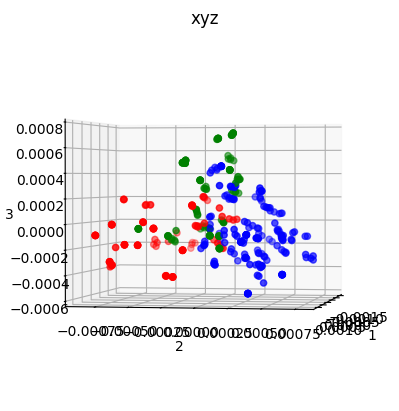

In [9]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import importlib
importlib.reload(C317)
d = C317.load_spectra(20)
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
%matplotlib inline
import sklearn.decomposition
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")

pca = sklearn.decomposition.PCA(n_components = 3)
pca_transposed = d.T
pca_array = pca.fit_transform(pca_transposed)
pca_retransposed = pca_array.T

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  column_names.append(i.name)
pca_df = pd.DataFrame(pca_retransposed, columns = column_names)

xdata = pca_df.iloc[0]
ydata = pca_df.iloc[1]
zdata = pca_df.iloc[2]

figure1 = plt.figure()
axes1 = figure1.add_subplot(projection="3d")
colours = ['red' if col.startswith('o') else 'green' if col.startswith('m') else 'blue' for col in pca_df.columns]
axes1.scatter(xdata, ydata, zdata, marker="o", c=colours)

axes1.set_xlabel("1")
axes1.set_ylabel("2")
axes1.set_zlabel("3")
axes1.set_title("xyz")
# axes1.legend(["x", "y", "z"])

axes1.azim=10
axes1.elev=1
axes1.dist=10

plt.show()